# 09 -- Target-Relative EDA (Bivariate + Multivariate Analysis)

**Pichle steps ka recap:**
- `06`: "General/Feature EDA" -- RAW features samjhe, target ki zaroorat nahi thi
- `07`: Ratios + target (`target_next_quarter_health`) banaye, test companies lock kiye (`company_split.json`)
- `08`: Ratios par sign-split winsorization (bounds sirf non-test companies se) -> `08_ratios_treated.parquet`

**Is notebook ka scope:** Ab TARGET exist karta hai, isliye "General EDA" se ALAG analysis: **features ka target ke SAATH rishta**,
aur target ki apni nature (kitna badalta hai, kahan data nahi).

**Leakage-safe:** jo bhi analysis target ke *labels* par hai (class balance, ratios by class, correlation, transitions) woh
**sirf train companies** par hai. Test companies ke labels is notebook mein kabhi nahi dekhe jate. Sirf "kis row ka target
maujood hai ya nahi" (availability) poore dataset par dekhi jati hai, kyunki isme label ki value nahi hoti.

**Koi hard-coded result nahi:** har number code se nikalta hai, isliye aap ke data par jo aaye wahi sahi hai.

## Working directory fix (zaroori)

In [12]:
import os
from pathlib import Path

if not Path("data").exists():
    os.chdir("..")

print("Working directory:", os.getcwd())
assert Path("data/processed").exists(), "data/processed nahi mila -- path check karo"

Working directory: d:\Developing_Projects\cross-industry-financial-analysis_Project


## Setup

In [13]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

PROCESSED_DIR = Path("data/processed")
REPORTS_DIR = Path("reports")
TARGET_EDA_DIR = REPORTS_DIR / "figures" / "target_relative_eda_charts"
TARGET_EDA_DIR.mkdir(parents=True, exist_ok=True)

INPUT_PATH = PROCESSED_DIR / "08_ratios_treated.parquet"

RATIO_COLS = ["current_ratio", "cash_ratio", "debt_to_equity", "debt_to_assets",
              "gross_margin", "operating_margin", "net_profit_margin", "roa", "roe", "asset_turnover"]
TARGET = "target_next_quarter_health"

sns.set_style("whitegrid")
print(f"Charts -> {TARGET_EDA_DIR}")

Charts -> reports\figures\target_relative_eda_charts


## Load 08 ka output + sirf train companies ka label-frame

In [14]:
df = pd.read_parquet(INPUT_PATH)
print(f"Shape: {df.shape}")

split_path = PROCESSED_DIR / "company_split.json"
assert split_path.exists(), "company_split.json nahi mili -- pehle 07 chalayen"
test_ciks = set(json.load(open(split_path))["test_ciks"])
is_test = df["cik"].astype(str).isin(test_ciks)

train_lab = df[df[TARGET].notna() & ~is_test].copy()      # label wali analysis ka frame: sirf train companies
assert not train_lab["cik"].astype(str).isin(test_ciks).any(), "MASLA: test company train_lab mein aa gayi!"

print(f"Target wali rows (sirf train companies): {len(train_lab)}  |  train companies: {train_lab['cik'].nunique()}")
print(f"Test companies ki rows is notebook mein label-analysis ke liye istemal NAHI hui: {(df[TARGET].notna() & is_test).sum()} rows bahar")

Shape: (58241, 104)
Target wali rows (sirf train companies): 27836  |  train companies: 3922
Test companies ki rows is notebook mein label-analysis ke liye istemal NAHI hui: 7050 rows bahar


---
# PART 1 -- Target Class Balance

**Kahani:** Class-balance ka sawal hai "kitne Healthy, kitne At-Risk?". Agar 95%/5% hota to model "hamesha majority bolo" kah kar
95% accuracy le leta bina kuch seekhe. Isliye model banane se pehle yeh dekhna zaroori hai, aur yehi **majority-class baseline** bhi hai
jis se model ko behtar hona chahiye.

                             rows  share
target_next_quarter_health              
At-Risk                     18042  0.648
Healthy                      9794  0.352

Majority-class baseline (hamesha 'At-Risk' bolo): 64.8%
Imbalance ratio (bara:chhota) = 1.84 : 1


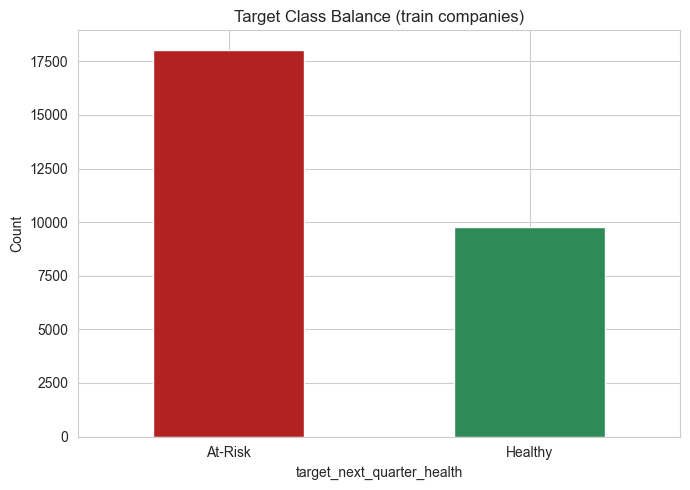

In [15]:
counts = train_lab[TARGET].value_counts()
share = train_lab[TARGET].value_counts(normalize=True)
print(pd.DataFrame({"rows": counts, "share": share.round(3)}).to_string())

majority_class = share.idxmax()
majority_baseline = share.max()
imbalance_ratio = share.max() / share.min()
print(f"\nMajority-class baseline (hamesha '{majority_class}' bolo): {majority_baseline:.1%}")
print(f"Imbalance ratio (bara:chhota) = {imbalance_ratio:.2f} : 1")

fig, ax = plt.subplots(figsize=(7, 5))
counts.plot(kind="bar", ax=ax, color=["firebrick" if k == "At-Risk" else "seagreen" for k in counts.index])
ax.set_title("Target Class Balance (train companies)")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(TARGET_EDA_DIR / "01_target_class_balance.png", dpi=120)
plt.show()

**Insight kaise padhein:** Imbalance ratio 3:1 ya 4:1 se kam ho to "mild" mana jata hai -- SMOTE jaisi nakli-data techniques ki zaroorat nahi
(aur financial ratios ke saath SMOTE khatarnak bhi hai, kyunki do companies ke ratios "mix" karke aisi company ban sakti hai jo asal mein exist hi
nahi kar sakti). `11` mein model ki accuracy ko is majority-baseline ke against dekha jayega, **lekin sirf isi se nahi** (Part 5 dekhein).

---
# PART 2 -- Sample-Selection Bias by Industry

**Kahani:** Target sirf un rows ke liye ban sakta hai jin ke paas T+1 mein `current_ratio` aur `NetIncomeLoss` dono hon, aur jin ka
(T, T+1) pair valid ho. Agar koi *industry* systematically in shartein poori nahi karti, to model us industry ko kam dekhega, aur uski
predictions kam bharosemand hongi.

Yahan sirf "target maujood hai ya nahi" dekha ja raha hai (label ki value nahi), isliye poore dataset par dekhna leakage nahi hai.

                     WITH_target  WITHOUT_target
industry_sector                                 
Manufacturing               48.6            21.4
Services                    21.7            13.9
Finance_RealEstate           8.3            49.1
Transport_Utilities          7.0             5.4
Retail                       5.3             2.7
Mining                       5.0             4.0
Wholesale                    2.4             1.5
Construction                 1.0             1.4
Agriculture                  0.8             0.5


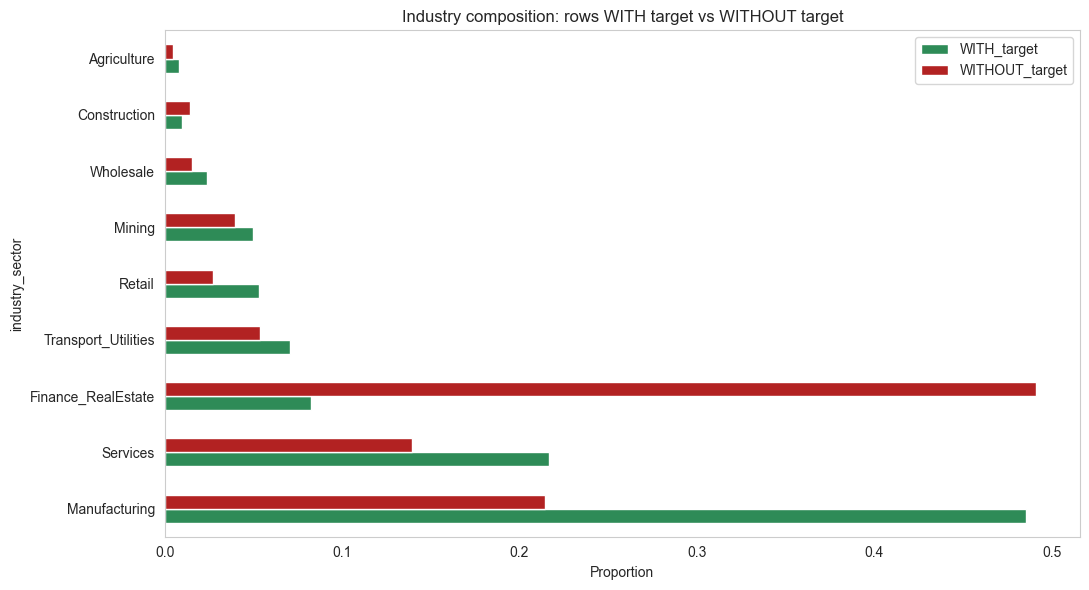

In [16]:
has_target = df[TARGET].notna()
comp = pd.DataFrame({
    "WITH_target": df[has_target]["industry_sector"].value_counts(normalize=True),
    "WITHOUT_target": df[~has_target]["industry_sector"].value_counts(normalize=True),
}).fillna(0).sort_values("WITH_target", ascending=False)
print((comp * 100).round(1).to_string())

fig, ax = plt.subplots(figsize=(11, 6))
comp.plot(kind="barh", ax=ax, color=["seagreen", "firebrick"])
ax.set_xlabel("Proportion")
ax.set_title("Industry composition: rows WITH target vs WITHOUT target")
plt.tight_layout()
plt.grid(False)
plt.savefig(TARGET_EDA_DIR / "02_selection_bias_by_industry.png", dpi=120)
plt.show()

**Wajah dhoondte hain (guess nahi):** Target NaN hone ke **do alag sabab** hain: (a) (T, T+1) pair hi valid nahi, ya (b) pair valid hai lekin T+1 mein
`current_ratio`/`NetIncomeLoss` missing hai. Neeche har sector ke liye dono ka hissa nikalte hain.

In [17]:
why = pd.DataFrame({
    "rows": df.groupby("industry_sector").size(),
    "has_target_%": df.groupby("industry_sector")[TARGET].apply(lambda s: s.notna().mean() * 100),
    "no_valid_pair_%": df.groupby("industry_sector")["is_valid_forward_pair"].apply(lambda s: (~s).mean() * 100),
    "pair_valid_but_label_missing_%": df.groupby("industry_sector").apply(
        lambda g: (g["is_valid_forward_pair"] & g[TARGET].isna()).mean() * 100, include_groups=False),
    "current_ratio_missing_%": df.groupby("industry_sector")["current_ratio"].apply(lambda s: s.isna().mean() * 100),
}).round(1).sort_values("has_target_%")
print(why.to_string())

worst = why.index[0]
print(f"\nSabse kam target-coverage wala sector: {worst} ({why.loc[worst, 'has_target_%']:.1f}% rows mein target)")

                      rows  has_target_%  no_valid_pair_%  pair_valid_but_label_missing_%  current_ratio_missing_%
industry_sector                                                                                                   
Finance_RealEstate   14353          20.1             17.5                            62.5                     72.5
Construction           668          50.4             18.3                            31.3                     34.9
Mining                2666          65.0             24.5                            10.4                     13.0
Transport_Utilities   3712          66.2             23.5                            10.3                      5.7
Services             10809          69.9             23.6                             6.5                      6.2
Wholesale             1198          69.9             22.4                             7.7                      4.3
Agriculture            390          72.1             23.8                       

**Insight kaise padhein:** Jis sector ki `pair_valid_but_label_missing_%` aur `current_ratio_missing_%` zyada hain, wahan sabab data ki nature hai
(jaise banks/REITs "classified balance sheet" nahi banate, isliye `AssetsCurrent`/`LiabilitiesCurrent` hi nahi hote). Iska matlab: **model un sectors ke liye
kam representative hoga**, aur un ki predictions kam bharosemand hongi. Yeh **documented limitation** hai (README mein), chhupai nahi jati.

---
# PART 3 -- Bivariate: Ratios by Target Class

**Kahani:** Agar Healthy aur At-Risk companies ke ratios bilkul ek jaise hote, to koi model kuch nahi seekh sakta. Aur agar unka rukh business-logic ke
ulta ho, to shak karna chahiye ke kahin galti hai. Isliye har ratio ka median har class mein dekhte hain.

Business-logic se **expected direction:** Healthy companies mein liquidity aur profitability zyada, aur `debt_to_assets` kam honi chahiye.
`debt_to_equity` ke liye koi seedhi ummeed nahi (profitable companies ko lenders zyada qarz bhi dete hain, aur zyada leverage risky bhi hai).

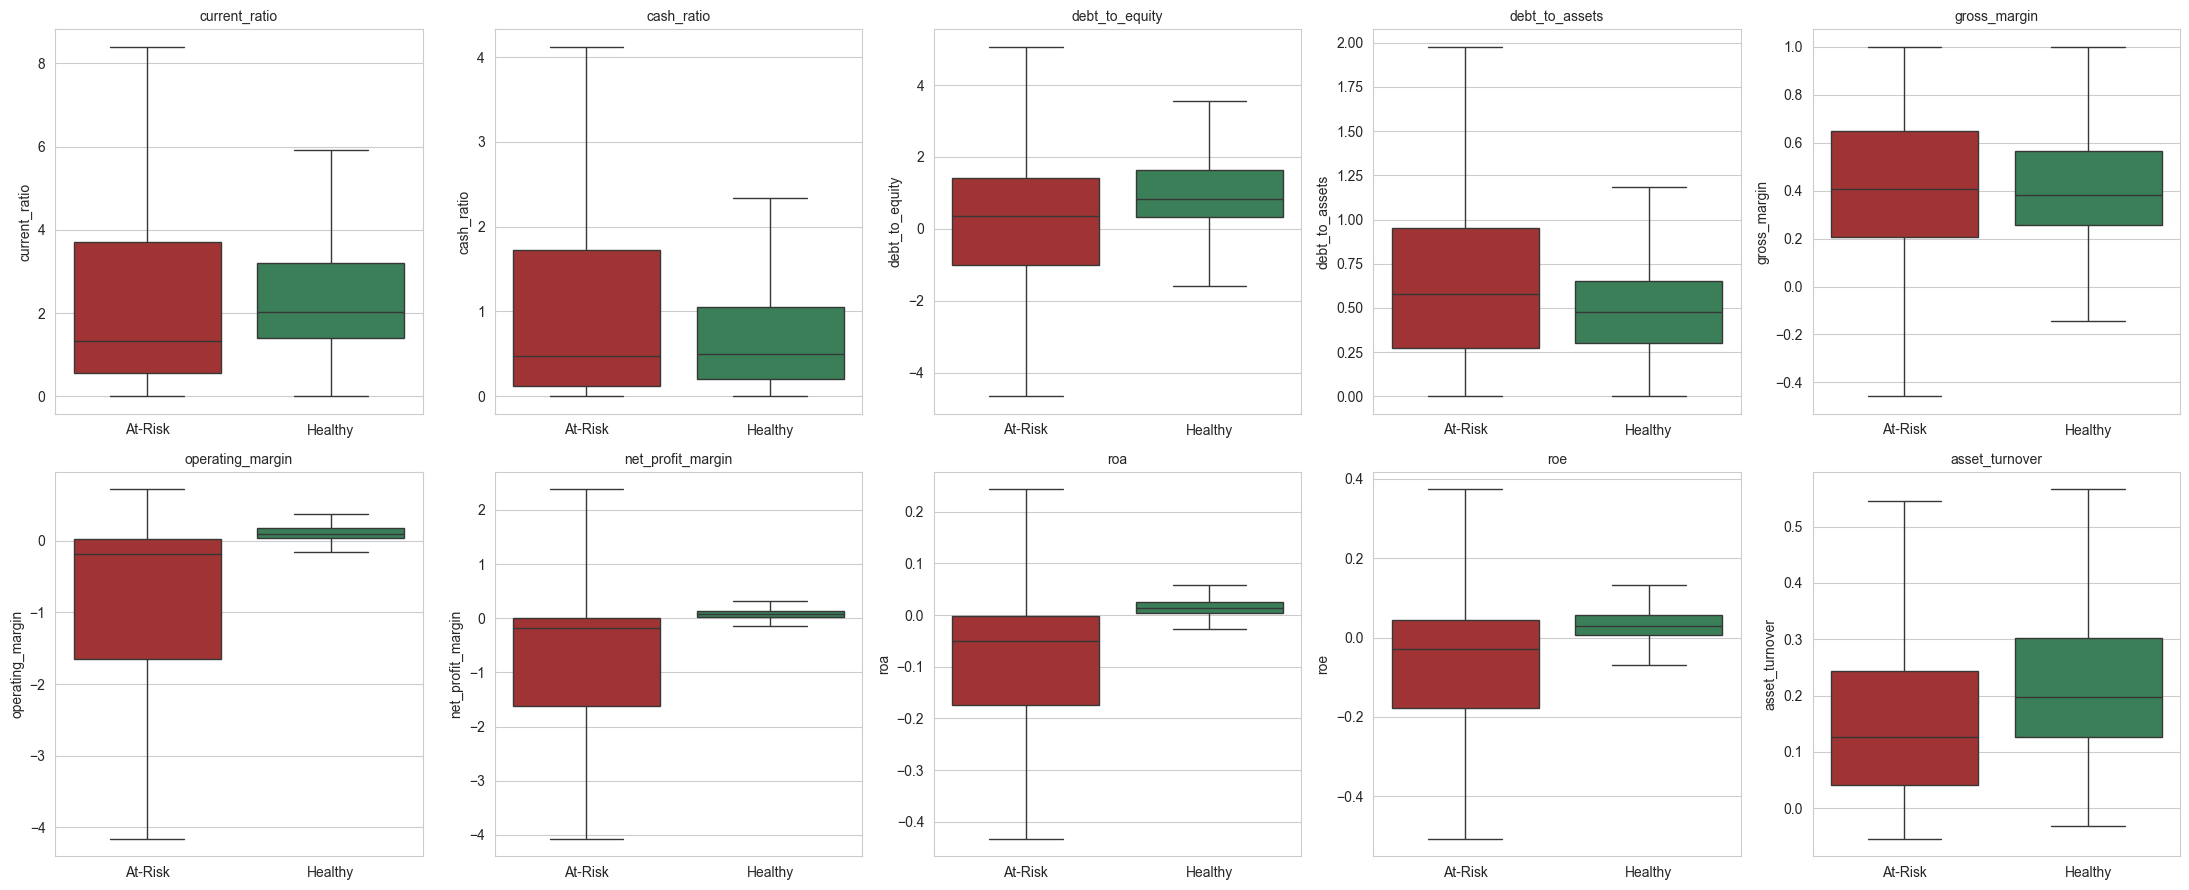

            ratio  median_Healthy  median_AtRisk              direction
    current_ratio           2.036          1.335               expected
       cash_ratio           0.494          0.480               expected
   debt_to_equity           0.820          0.353 koi seedhi ummeed nahi
   debt_to_assets           0.479          0.582               expected
     gross_margin           0.383          0.407    UNEXPECTED (review)
 operating_margin           0.098         -0.178               expected
net_profit_margin           0.071         -0.178               expected
              roa           0.013         -0.051               expected
              roe           0.028         -0.029               expected
   asset_turnover           0.197          0.126               expected


In [18]:
HIGHER_IF_HEALTHY = ["current_ratio", "cash_ratio", "gross_margin", "operating_margin", "net_profit_margin", "roa", "roe", "asset_turnover"]
LOWER_IF_HEALTHY = ["debt_to_assets"]

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
for ax, col in zip(axes.flatten(), RATIO_COLS):
    sns.boxplot(data=train_lab, x=TARGET, y=col, hue=TARGET, ax=ax, showfliers=False,
                palette={"Healthy": "seagreen", "At-Risk": "firebrick"}, legend=False)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
plt.tight_layout()
plt.savefig(TARGET_EDA_DIR / "03_ratios_by_health_class.png", dpi=120)
plt.show()

rows = []
for col in RATIO_COLS:
    h = train_lab.loc[train_lab[TARGET] == "Healthy", col].median()
    a = train_lab.loc[train_lab[TARGET] == "At-Risk", col].median()
    if col in HIGHER_IF_HEALTHY:
        verdict = "expected" if h > a else "UNEXPECTED (review)"
    elif col in LOWER_IF_HEALTHY:
        verdict = "expected" if h < a else "UNEXPECTED (review)"
    else:
        verdict = "koi seedhi ummeed nahi"
    rows.append({"ratio": col, "median_Healthy": round(h, 3), "median_AtRisk": round(a, 3), "direction": verdict})
direction_table = pd.DataFrame(rows)
print(direction_table.to_string(index=False))

**Insight kaise padhein:** `expected` wale ratios business-logic se match karte hain. `UNEXPECTED` wala koi ratio ho to use bug na samjhein, pehle sabab dhoondein
(jaise gross_margin agar dono classes mein lagbhag barabar ho to iska matlab hai yeh feature is target ke liye kamzor hai; `10` mein isay dekha jayega).
`debt_to_equity` ka rukh aksar Healthy mein zyada nikalta hai: profitable companies ko lenders zyada qarz dete hain, jabke struggling companies ka credit-access
kam ho jata hai (qarz kam milta hai, samajhdari se nahi).

---
# PART 4 -- Statistical Strength: Point-Biserial Correlation

**Kahani:** Box plot rukh dikhata hai, lekin **kitna mazboot rishta** hai yeh number mein chahiye. Point-biserial correlation tab use hoti hai jab
ek variable number ho (ratio) aur doosra do-class (Healthy=1 / At-Risk=0).

- **r** = rishta kitna *mazboot* hai (-1 se +1; 0 = koi rishta nahi)
- **p** = kya yeh rishta *asli* hai ya sirf ittefaq (chhota p = asli)

Yeh do alag sawal hain: bare sample (yahan hazaron rows) mein chhota sa rishta bhi "significant" ban jata hai, magar iska matlab yeh nahi ke woh mazboot bhi hai.

                        r    p        n
debt_to_assets    -0.1150  0.0  23553.0
cash_ratio        -0.1041  0.0  22465.0
current_ratio     -0.0272  0.0  27660.0
debt_to_equity     0.0361  0.0  22570.0
gross_margin       0.0383  0.0  12674.0
roe                0.0733  0.0  26182.0
operating_margin   0.1050  0.0  19286.0
net_profit_margin  0.1057  0.0  20450.0
roa                0.1096  0.0  27429.0
asset_turnover     0.1245  0.0  21232.0


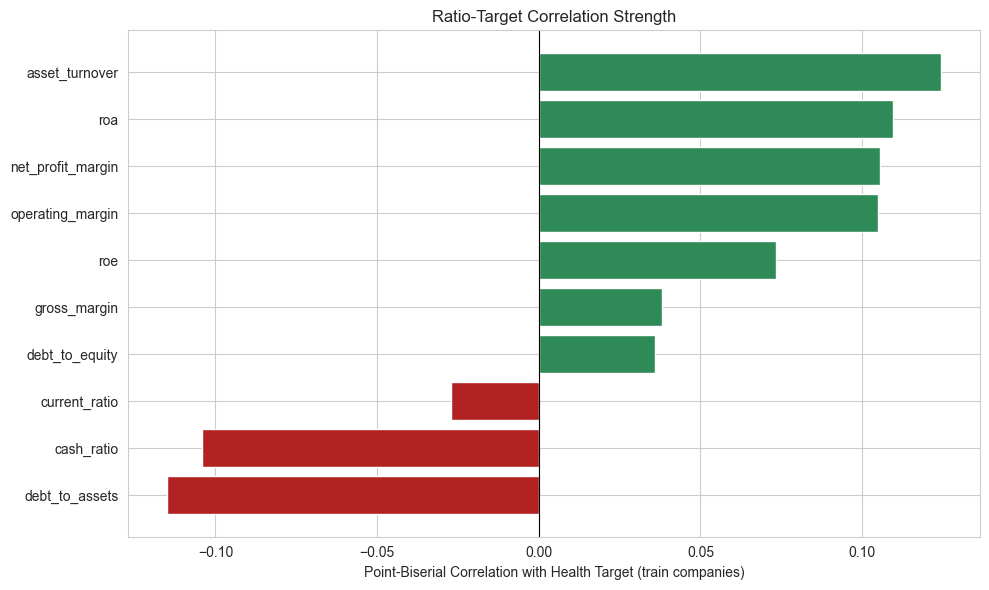


Sabse mazboot |r|: asset_turnover (+0.125);   sab ka median |r| = 0.105
Saare p < 0.001 hain? True


In [19]:
train_lab["target_binary"] = (train_lab[TARGET] == "Healthy").astype(int)

corr_results = {}
for col in RATIO_COLS:
    sub = train_lab[[col, "target_binary"]].dropna()
    r, p = stats.pointbiserialr(sub["target_binary"], sub[col])
    corr_results[col] = {"r": r, "p": p, "n": len(sub)}
corr_df = pd.DataFrame(corr_results).T.sort_values("r")
print(corr_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(corr_df.index, corr_df["r"], color=["firebrick" if v < 0 else "seagreen" for v in corr_df["r"]])
ax.set_xlabel("Point-Biserial Correlation with Health Target (train companies)")
ax.set_title("Ratio-Target Correlation Strength")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(TARGET_EDA_DIR / "04_correlation_with_health.png", dpi=120)
plt.show()

strongest = corr_df["r"].abs().idxmax()
print(f"\nSabse mazboot |r|: {strongest} ({corr_df.loc[strongest, 'r']:+.3f});   sab ka median |r| = {corr_df['r'].abs().median():.3f}")
print(f"Saare p < 0.001 hain? {bool((corr_df['p'] < 0.001).all())}")

**Insight kaise padhein:** Agar saare p bohat chhote hain lekin |r| chhote hain (jaise 0.05 se 0.15), to matlab: rishte **asli** hain magar **kamzor**.
Koi ek ratio "silver bullet" nahi, model ko kai kamzor signals ko **mila kar** (aur non-linear tareeqe se) use karna hoga. Isi liye `12` mein tree-based model ko
simple linear model se compare kiya jata hai.

**Zaroori nuance:** `current_ratio` ka correlation kam hona hairan kar sakta hai, kyunki yeh target ki definition ka hissa hai. Lekin feature **T** ka hai aur target **T+1** ka,
aur company ka status quarter-to-quarter badalta hai. Agar yeh correlation bohat mazboot hoti to task trivial hota.

---
# PART 5 -- Persistence aur Transitions: target kitna badalta hai? (NAYA)

**Kahani:** Sab se aasan andaza hai "jo company abhi Healthy hai wahi agle quarter bhi Healthy rahegi, aur jo At-Risk hai wahi At-Risk". Isay **persistence baseline** kehte hain.
Agar yeh baseline pehle hi bohat achi ho, to model ki asal value sirf tab hai jab woh yeh baseline se behtar kare, khaaskar un companies mein jahan status **badalta** hai.

Yeh part model banane se pehle target ki nature samajhne ke liye hai. `eval_*` columns (`07` se) sirf isi tarah ke evaluation ke liye hain, model ke input nahi.

Rows jin ka T ka apna status compute ho saka: 27445 of 27836

Transition counts (rows = T ka status, columns = T+1 ka status):
target_next_quarter_health  At-Risk  Healthy
eval_current_health_state                   
At-Risk                       16125     1707
Healthy                        1694     7919

Transition probabilities (har row ka 100%):
target_next_quarter_health  At-Risk  Healthy
eval_current_health_state                   
At-Risk                        90.4      9.6
Healthy                        17.6     82.4

Persistence baseline accuracy ('jo abhi hai wahi rahega'): 87.6%
Status badalne wali rows: 12.4%

Persistence, T+1 ki filing ke type ke hisaab se:
                               rows  persistence_%
eval_next_is_annual_filing                        
T+1 quarterly filing        21392.0           86.9
T+1 annual filing            6053.0           90.0


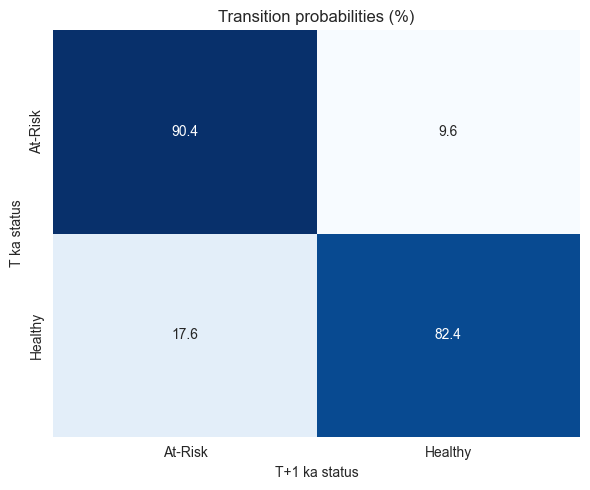

In [20]:
lab = train_lab[train_lab["eval_current_health_state"].notna()].copy()
print(f"Rows jin ka T ka apna status compute ho saka: {len(lab)} of {len(train_lab)}")

counts_t = pd.crosstab(lab["eval_current_health_state"], lab[TARGET])
trans = pd.crosstab(lab["eval_current_health_state"], lab[TARGET], normalize="index")
print("\nTransition counts (rows = T ka status, columns = T+1 ka status):")
print(counts_t.to_string())
print("\nTransition probabilities (har row ka 100%):")
print((trans * 100).round(1).to_string())

persistence_acc = (lab["eval_current_health_state"] == lab[TARGET]).mean()
changed_share = 1 - persistence_acc
print(f"\nPersistence baseline accuracy ('jo abhi hai wahi rahega'): {persistence_acc:.1%}")
print(f"Status badalne wali rows: {changed_share:.1%}")

by_next = lab.groupby("eval_next_is_annual_filing").apply(
    lambda g: pd.Series({"rows": len(g), "persistence_%": (g["eval_current_health_state"] == g[TARGET]).mean() * 100}), include_groups=False)
by_next.index = by_next.index.map({True: "T+1 annual filing", False: "T+1 quarterly filing"})
print("\nPersistence, T+1 ki filing ke type ke hisaab se:")
print(by_next.round(1).to_string())

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(trans * 100, annot=True, fmt=".1f", cmap="Blues", ax=ax, cbar=False)
ax.set_xlabel("T+1 ka status"); ax.set_ylabel("T ka status")
ax.set_title("Transition probabilities (%)")
plt.tight_layout()
plt.savefig(TARGET_EDA_DIR / "05_transition_matrix.png", dpi=120)
plt.show()

**Insight kaise padhein:**
- **Persistence baseline** wahi number hai jo majority-baseline se kaafi upar ho sakta hai. **Model ki asal value is se behtar hone mein hai**, sirf "majority se behtar" hone mein nahi.
- Transition table dikhata hai kis taraf zyada badlav hai: Healthy se At-Risk (girawat) ya At-Risk se Healthy (recovery). Business ke hisaab se **Healthy se At-Risk** girne wali companies pakadna
  sabse kaam ki cheez hai (early warning).
- Agar persistence T+1 ke annual aur quarterly filing mein bohat alag ho, to woh is baat ka ishara hai ke label ki maana (saal ka average quarter vs asli quarter) thodi alag hai; `11` mein model in dono par alag evaluate hota hai.

---
# PART 6 -- Target-Relative Missingness (Healthy vs At-Risk)

**Zaroori check:** Kya At-Risk companies structurally KAM data report karti hain? Agar haan, to "data missing hai" khud ek chhupa hua predictor ban jata (model asal
ratios ke bajaye missingness dekh kar hi At-Risk keh deta).

In [21]:
missing_by_class = pd.DataFrame({
    "Healthy_missing_%": train_lab[train_lab[TARGET] == "Healthy"][RATIO_COLS].isna().mean() * 100,
    "AtRisk_missing_%": train_lab[train_lab[TARGET] == "At-Risk"][RATIO_COLS].isna().mean() * 100,
})
missing_by_class["diff (AtRisk - Healthy)"] = missing_by_class["AtRisk_missing_%"] - missing_by_class["Healthy_missing_%"]
print(missing_by_class.round(2).sort_values("diff (AtRisk - Healthy)", ascending=False).to_string())
print(f"\nSabse bara farq: {missing_by_class['diff (AtRisk - Healthy)'].abs().max():.1f} percentage points")

# Mechanism ka live check: revenue missing hona aur At-Risk hone ka rishta
rev_missing = train_lab["Revenue_final"].isna()
atrisk_when_missing = (train_lab.loc[rev_missing, TARGET] == "At-Risk").mean()
atrisk_when_present = (train_lab.loc[~rev_missing, TARGET] == "At-Risk").mean()
print(f"\nRevenue missing wali rows: {rev_missing.mean():.1%} of train rows")
print(f"At-Risk share jab Revenue MISSING: {atrisk_when_missing:.1%}   vs  jab Revenue MAUJOOD: {atrisk_when_present:.1%}")

                   Healthy_missing_%  AtRisk_missing_%  diff (AtRisk - Healthy)
net_profit_margin              15.89             32.31                    16.43
asset_turnover                 15.00             28.46                    13.46
gross_margin                   45.89             59.13                    13.24
operating_margin               23.24             34.77                    11.54
cash_ratio                     15.19             21.52                     6.33
roa                             1.03              1.70                     0.66
current_ratio                   0.83              0.53                    -0.30
roe                             7.00              5.37                    -1.64
debt_to_assets                 20.86             12.42                    -8.44
debt_to_equity                 25.05             15.59                    -9.45

Sabse bara farq: 16.4 percentage points

Revenue missing wali rows: 23.4% of train rows
At-Risk share jab Revenue MISSI

**Insight kaise padhein (asli data ke hisaab se):** Revenue par mabni ratios (`net_profit_margin`, `asset_turnover`, `gross_margin`, `operating_margin`) At-Risk rows mein **zyada baar missing**
hain, aur upar ka live check dikhata hai ke `Revenue` missing hone par At-Risk ka hissa bhi zyada hota hai. Yani "revenue missing hona" khud ek **kamzor predictor** hai.

**Wajah (do hisse):** (1) kai At-Risk companies pre-revenue hoti hain (revenue hi nahi hota), (2) kuch companies, khaaskar banks/financials, revenue un tags mein report karti hain jo hamare
core tags mein shamil nahi (jaise interest income); raw data mein aise tags maujood hain (README ki limitations mein detail).

**Yeh leakage nahi hai** (T par ye maloom hota hai), lekin model ke liye ek shortcut ban sakta hai. Isliye `11` mein performance **"revenue maujood" rows par alag** bhi report hoti hai: wahi asal imtihan hai.

---
# PART 7 -- Save + Sanity Checks

In [22]:
corr_df.to_csv(REPORTS_DIR / "09_health_target_correlations.csv")
trans.to_csv(REPORTS_DIR / "09_transition_matrix.csv")
print("[SAVED] reports/09_health_target_correlations.csv")
print("[SAVED] reports/09_transition_matrix.csv")

expected_charts = ["01_target_class_balance.png", "02_selection_bias_by_industry.png", "03_ratios_by_health_class.png",
                   "04_correlation_with_health.png", "05_transition_matrix.png"]
assert all((TARGET_EDA_DIR / c).exists() for c in expected_charts), "MASLA: koi chart nahi bana"
print(f"[OK] Saare {len(expected_charts)} target-relative EDA charts bane.")

assert not train_lab["cik"].astype(str).isin(test_ciks).any()
print("[OK] Label-analysis sirf train companies par hui (test companies ke labels nahi dekhe).")

print(f"\nDataset row count (unchanged, ye notebook sirf ANALYZE karti hai): {len(df)}")
print("\nAgla step: 10_feature_selection.ipynb")

[SAVED] reports/09_health_target_correlations.csv
[SAVED] reports/09_transition_matrix.csv
[OK] Saare 5 target-relative EDA charts bane.
[OK] Label-analysis sirf train companies par hui (test companies ke labels nahi dekhe).

Dataset row count (unchanged, ye notebook sirf ANALYZE karti hai): 58241

Agla step: 10_feature_selection.ipynb
